In [ ]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using SparseArrays
using DelimitedFiles
using Plots

In [ ]:
py"""
from petsc4py import PETSc
from slepc4py import SLEPc
import sys
import numpy as np;"""

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end

In [111]:
N_cheb = 199
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = 30
num = 1
omega = 0
R = 290
be = 0.077
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

([0.0; 6.993301171352998e-5; … ; 9.507812671209326e-32; 9.507812671209326e-32;;], [0.0; -8.443025054971694e-5; … ; -1.0; -1.0;;], [7.50356186372694e-27; -9.586977326048397e-9; … ; -0.884474097792174; -0.884474097792174;;], [1.0; 1.0000011531164075; … ; 0.9999999853635262; 0.9999999853635262;;], [1.0; 0.9999988468849222; … ; 1.000000014636474; 1.000000014636474;;], [0.0; 0.00013707944972341863; … ; 30.0; 30.0;;], [-0.6666666666666666; -0.6666674354109383; … ; -0.6666666569090174; -0.6666666569090174;;], [1.3888888888888888; 1.3888904904394548; … ; 1.388888868560453; 1.388888868560453;;], [-12000.454545456723 14590.921919246277 … -0.9091475537485056 0.45454545454545453; -3647.3090422983755 1823.5408908347508 … 0.45454958065615236 -0.22726062903512984; … ; 2.7175294799946713e-9 -5.435397634851064e-9 … -2.1805475721239733e-5 4.361366897195741e-5; -0.0 0.0 … -0.0 0.0], [8.641439460754469e7 -1.3731251765340126e8 … 21785.379665164575 -10892.00570716381; 3.991253504897248e7 -5.7071521660319254

eigval * sc = ComplexF64[0.3828983974378446 - 0.0016045230550163264im, 0.22627941178738395 + 0.05174139203744237im, 0.24349615276116385 + 0.10838406625473393im]


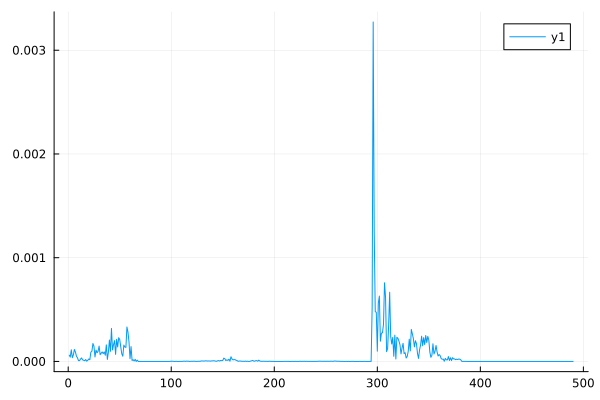

In [74]:
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
L0 = L0_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1 = L1_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2 = L2_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0,L1,L2]); 
sc = 1;
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
eigval,eigvec = iar(nep2, σ = 0.4/sc, neigs = 3,maxit = 500,tol=1e-12)
vel_full,vel = eig_full(eigvec,N_cheb,2,15)
@show eigval * sc
res = (L0 +  (eigval[1]*sc)*L1 + (eigval[1]*sc)^2*L2) * eigvec[:,1];
plot(abs.(res))

eigval_A = ComplexF64[0.38289846969721886 + 0.0016048678722503178im]


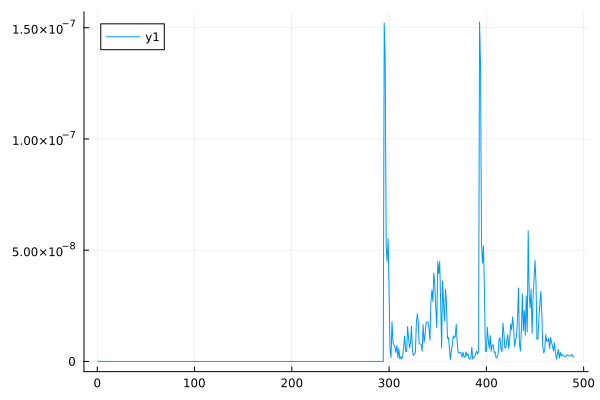

In [73]:
L0_A_raw = L0_raw';
L1_A_raw = L1_raw';
L2_A_raw = L2_raw';
L0_A = L0_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = L1_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = L2_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]); 
eigval_A,eigvec_A = iar(nep,σ = 0.4 , neigs = num ,maxit = 500,tol=1e-18)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1,15)
@show eigval_A
res = (L0_A +  (eigval_A[1])*L1_A + (eigval_A[1])^2*L2_A) * eigvec_A;
plot(abs.(res))

In [ ]:
@show eigval_A,eigval

In [72]:
Q = abs(vel_full_A' * ((L1_raw + (eigval[1]+eigval_A[1]) .* L2_raw) * vel_full))

0.0043132364824204125

In [ ]:
plot(z,abs.(vel[1]),label = "u",xlims=[0,30],ylims=[0,0.4001]) 
plot!(z,abs.(vel[2]),label = "v") 
plot!(z,abs.(vel[3]),label = "w") 
# plot(z,abs.(vel[4]),label = "rho")

In [ ]:
plot(z,abs.(vel_A[1]),label = "u",xlims=[0,30],ylims=[0,0.2001])
plot!(z,abs.(vel_A[2]),label = "v")
plot!(z,abs.(vel_A[3]),label = "w")

In [112]:
coff = [0 0]
# for R = 320 : 2 : 380
    R = 330
    be = 32/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
    L0 = L0_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    L1 = L1_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    L2 = L2_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep, σ = 0.4, neigs = 1,maxit = 500,tol=1e-13)
    vel_full,vel = eig_full(eigvec,N_cheb,1,15)
    L0_A_raw = L0_raw';
    L1_A_raw = L1_raw';
    L2_A_raw = L2_raw';
    L0_A = L0_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    L1_A = L1_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    L2_A = L2_A_raw[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
    nep = PEP([L0_A,L1_A,L2_A]); 
    eigval_A,eigvec_A = iar(nep,σ = 0.4 , neigs = 1 ,maxit = 500,tol=1e-14)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1,15)
    Q = abs(vel_full_A' * ((L1_raw + (eigval[1]+eigval_A[1]) .* L2_raw) * vel_full))
    x0 = R
    alpha = eigval[1]
    u_wall = -(D*F)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    v_wall = -(D*G)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    w_wall = 0
    vel[1][1] = u_wall
    vel[2][1] = v_wall
    vel[3][1] = w_wall
    phi = [vel[1];vel[2];vel[3];vel[4];vel[5]]
    dphi = [D*vel[1];D*vel[2];D*vel[3];D*vel[4];D*vel[5]]
    psi = [vel_A[1];vel_A[2];vel_A[3];vel_A[4];vel_A[5]]
    dpsi = [D*vel_A[1];D*vel_A[2];D*vel_A[3];D*vel_A[4];D*vel_A[5]]
    BC = (Tw/R) * (D*vel_A[1])[1] * u_wall + (3Tw/4R) * (D*vel_A[2])[1] * v_wall
    Cr = abs(-im * BC/Q)
    @show Cr,abs((D*vel_A[1])[1]),abs((D*vel_A[2])[1])
#     coff = [coff;[R Cr]]
#     writedlm("Cr_lof.dat",coff[2:end,:])
# end

(Cr, abs((D * vel_A[1])[1]), abs((D * vel_A[2])[1])) = (3.322464501070405e-5, 0.2519146476935527, 0.0013749491068211178)


(3.322464501070405e-5, 0.2519146476935527, 0.0013749491068211178)

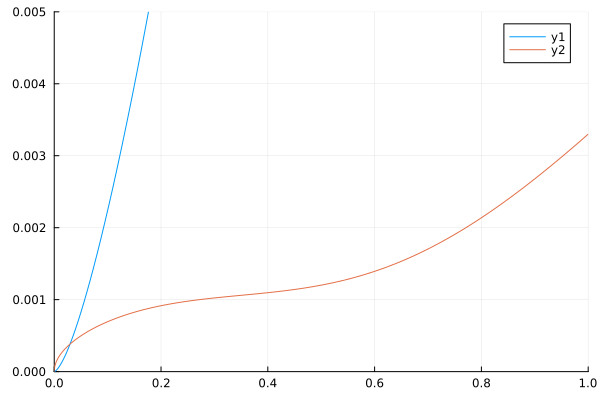

In [115]:
plot(z,abs.(vel_A[2]),xlims=[0,1],ylims=[0,0.005])
plot!(z,abs.(vel_A[1]))

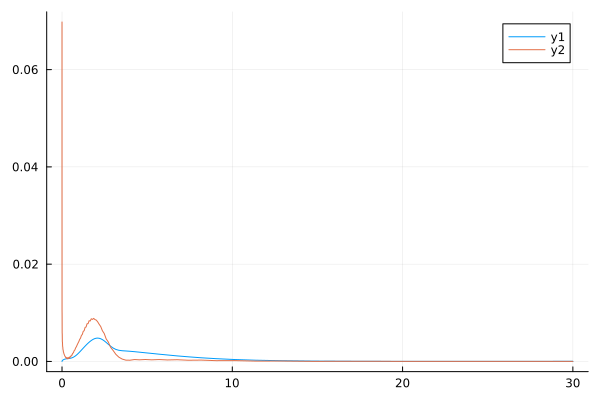

In [94]:
plot(z,abs.(vel_A[1]))
plot!(z,abs.(D*vel_A[1]))

In [100]:
abs.(D*vel_A[2])

100-element Vector{Float64}:
 0.0014781906456442654
 0.0012104248039682408
 0.0033795963923725306
 0.004134292934637405
 0.0062681076846708
 0.00701785252268387
 0.00905530162554926
 0.009782394546957698
 0.011685990344806786
 0.012395982620963005
 ⋮
 1.776411381804525e-5
 8.54580768339452e-6
 3.4423032724979966e-6
 1.0754267598495847e-6
 2.0164248852507003e-7
 6.624584887844288e-8
 5.4650379936738145e-8
 1.6374968084024116e-8
 0.0

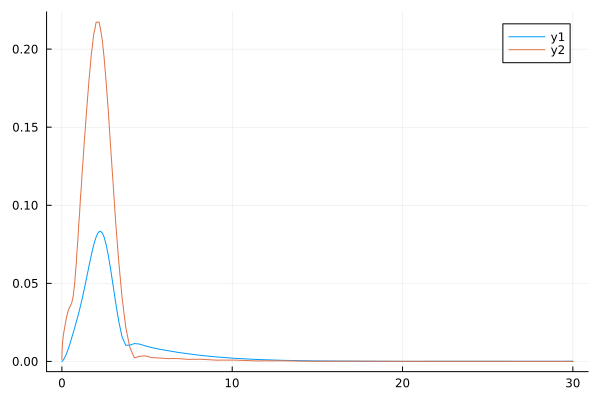

In [93]:
plot(z,abs.(vel_A[2]))
plot!(z,abs.(D*vel_A[2]))

In [ ]:
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end

In [ ]:
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C
end

In [ ]:
function tr(A,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
            C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end
    return C'
end

In [ ]:
function eig_full(eigvec,N_cheb,num,zmax)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-9,0im)
    insert!(eigvec,4N-7,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,1,0im)
    u = eigvec[1:N,1]
    v = eigvec[N+1:2N,1]
    w = eigvec[2N+1:3N,1]
    rho = eigvec[3N+1:4N,1]
    T = eigvec[4N+1:5N,1]
    # index = findall(x->x==zmax,z)[1][1]
    # u[index:end] .= 0
    # v[index:end] .= 0
    # w[index:end] .= 0
    # rho[index:end] .= 0
    # T[index:end] .= 0
    eigvec = [u;v;w;rho;T]
    return eigvec,(u,v,w,rho,T)
end

In [ ]:
A0 = tr(cof.D1,N_cheb) + im * be * tr(cof.B,N_cheb) - im * omega * tr(cof.Ta,N_cheb) - be^2 * tr(cof.Vyy,N_cheb) - mat_diff(cof.C,D,N_cheb) - im *be*mat_diff(cof.Vyz,D,N_cheb)+ mat_diff(cof.Vzz,D2,N_cheb) - (tr(cof.C,N_cheb)+ im * be * mat_diff(cof.Vyz,D,N_cheb) - 2 * mat_diff(cof.Vzz,D,N_cheb)) * kron(I(5),D)+ tr(cof.Vzz,N_cheb) * kron(I(5),D2)
A1 = im * tr(cof.A,N_cheb) - be * tr(cof.Vxy,N_cheb) + im * mat_diff(cof.Vxz,D,N_cheb) - im * tr(cof.Vxz,N_cheb) * kron(I(5),D) 
A2 = -tr(cof.Vxx,N_cheb)
A0 = A0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
A1 = A1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
A2 = A2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = 0.38, neigs = 1 ,maxit = 500,tol=1e-12)
eigval

In [ ]:
vel_full,vel = eig_full(eigvec,N_cheb,1,15)

In [ ]:
plot(z,abs.(vel[2])) 